# COSMOS-UK Evapotranspiration — Exploratory Analysis

Dataset: sub-daily actual ET for 45 UK monitoring sites, 2014–2024.  
Source: NERC EDS / UK Centre for Ecology and Hydrology  
DOI: [10.5285/c0b5caf4-c14a-49e8-a720-2401c8d3d135](https://doi.org/10.5285/c0b5caf4-c14a-49e8-a720-2401c8d3d135)

All flux data used here are from the **L2 (QC'd)** files. Missing values are `-9999` in the raw CSVs, loaded as `NaN`.

In [1]:
import importlib, subprocess, sys
for pkg in ['pandas', 'matplotlib', 'numpy', 'seaborn']:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

In [2]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='tab10')

DATA_DIR = 'data'

## 1. Site metadata

In [3]:
meta = pd.read_csv(f'{DATA_DIR}/cosmos-uk_sitemetadata_2014-2024.csv',
                   parse_dates=['START_DATE', 'END_DATE',
                                'DATE_INSTALLED', 'DATE_DECOMMISSIONED'],
                   dayfirst=True)

print(f"{len(meta)} sites")
meta[['SITE_NAME','SITE_ID','LATITUDE','LONGITUDE','ALTITUDE',
      'SOIL_TYPE','LAND_COVER']].head(10)

45 sites


/tmp/ipykernel_2729918/2222660146.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  meta = pd.read_csv(f'{DATA_DIR}/cosmos-uk_sitemetadata_2014-2024.csv',


,SITE_NAME,SITE_ID,LATITUDE,LONGITUDE,ALTITUDE,SOIL_TYPE,LAND_COVER
0,Balruddery,BALRD,56.482297,-3.111488,95,Mineral soil,Arable and horticulture
1,Bickley Hall,BICKL,53.026350,-2.700530,78,Mineral soil,Improved grassland
2,Bunny Park,BUNNY,52.860730,-1.126850,39,Mineral soil,Arable and horticulture
3,Cardington,CARDT,52.105601,-0.424644,29,Mineral soil,Improved grassland
4,Chimney Meadows,CHIMN,51.708021,-1.478766,66,Calcareous mineral soil,Improved grassland
5,Chobham Common,CHOBH,51.367821,-0.597484,39,Organic soil over mineral soil,Heather grassland
6,Cochno,COCHN,55.941421,-4.403543,170,Mineral soil,Improved grassland
7,Cockle Park,COCLP,55.216013,-1.694374,84,Mineral soil,Arable and horticulture
8,Crichton,CRICH,55.043057,-3.583386,46,Mineral soil,Arable and horticulture (previously improved g...
9,Easter Bush,EASTB,55.867392,-3.207115,190,Mineral soil,Improved grassland


In [4]:
meta['LAND_COVER'].value_counts().rename('site count').to_frame()

,site count
LAND_COVER,
Improved grassland,20
Arable and horticulture,14
Acid grassland,3
Heather grassland,2
Arable and horticulture (previously improved grassland),2
Calcareous grassland,2
Heather,1
Improved grassland (previously arable and horticulture),1


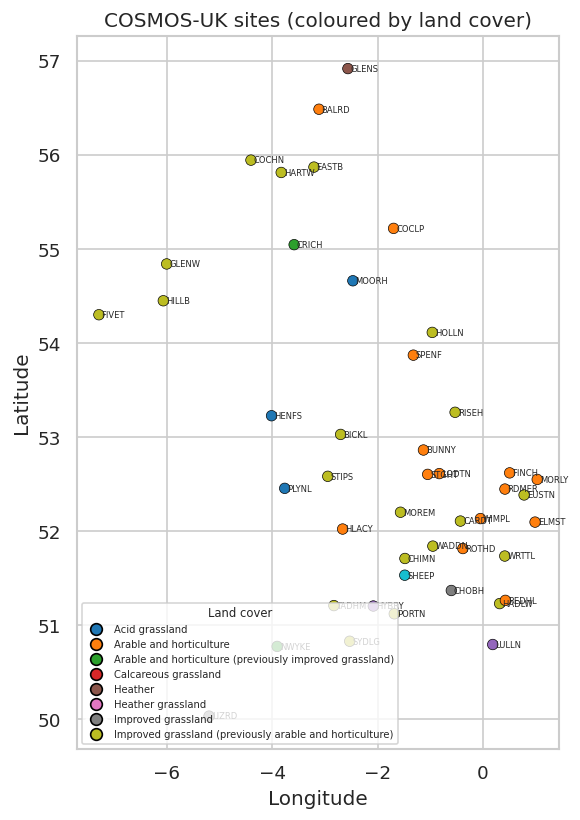

In [5]:
lc_codes = meta['LAND_COVER'].astype('category').cat.codes
fig, ax = plt.subplots(figsize=(5, 7))
ax.scatter(meta['LONGITUDE'], meta['LATITUDE'],
           c=lc_codes, cmap='tab10', s=40, edgecolors='k', linewidths=0.4)
for _, row in meta.iterrows():
    ax.text(row['LONGITUDE'] + 0.05, row['LATITUDE'], row['SITE_ID'],
            fontsize=5, va='center')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('COSMOS-UK sites (coloured by land cover)')
cats = meta['LAND_COVER'].astype('category').cat.categories
handles = [plt.Line2D([0],[0], marker='o', color='w',
                      markerfacecolor=plt.cm.tab10(i/len(cats)),
                      markeredgecolor='k', markersize=7)
           for i in range(len(cats))]
ax.legend(handles, cats, fontsize=6, title='Land cover', title_fontsize=7,
          loc='lower left')
plt.tight_layout()
plt.show()

## 2. Load all L2 data

In [6]:
l2_files = sorted(glob.glob(f'{DATA_DIR}/*_l2_*.csv'))
print(f"Found {len(l2_files)} L2 files")

frames = [pd.read_csv(f, parse_dates=['DATE_TIME'], na_values=-9999)
          for f in l2_files]

all_l2 = pd.concat(frames, ignore_index=True)
all_l2['DATE_TIME'] = pd.to_datetime(all_l2['DATE_TIME'], utc=True)
all_l2['YEAR']  = all_l2['DATE_TIME'].dt.year
all_l2['MONTH'] = all_l2['DATE_TIME'].dt.month

print(f"Total rows: {len(all_l2):,}")
print(f"Date range: {all_l2['DATE_TIME'].min()} → {all_l2['DATE_TIME'].max()}")
all_l2.head(3)

Found 45 L2 files


Total rows: 6,189,116
Date range: 2014-04-24 14:00:00+00:00 → 2024-08-14 09:30:00+00:00


,DATE_TIME,SITE_ID,H,H_FLAG,LE,ET,TAU,TAU_FLAG,SHF,YEAR,MONTH
0,2015-06-10 16:30:00+00:00,BALRD,80.054,0.0,206.589,0.08428,-0.07540,0.0,46.757,2015,6
1,2015-06-10 17:00:00+00:00,BALRD,60.057,0.0,179.566,0.07325,-0.07617,0.0,37.377,2015,6
2,2015-06-10 17:30:00+00:00,BALRD,49.538,0.0,142.945,0.05831,-0.06628,0.0,25.717,2015,6


## 3. Data availability per site

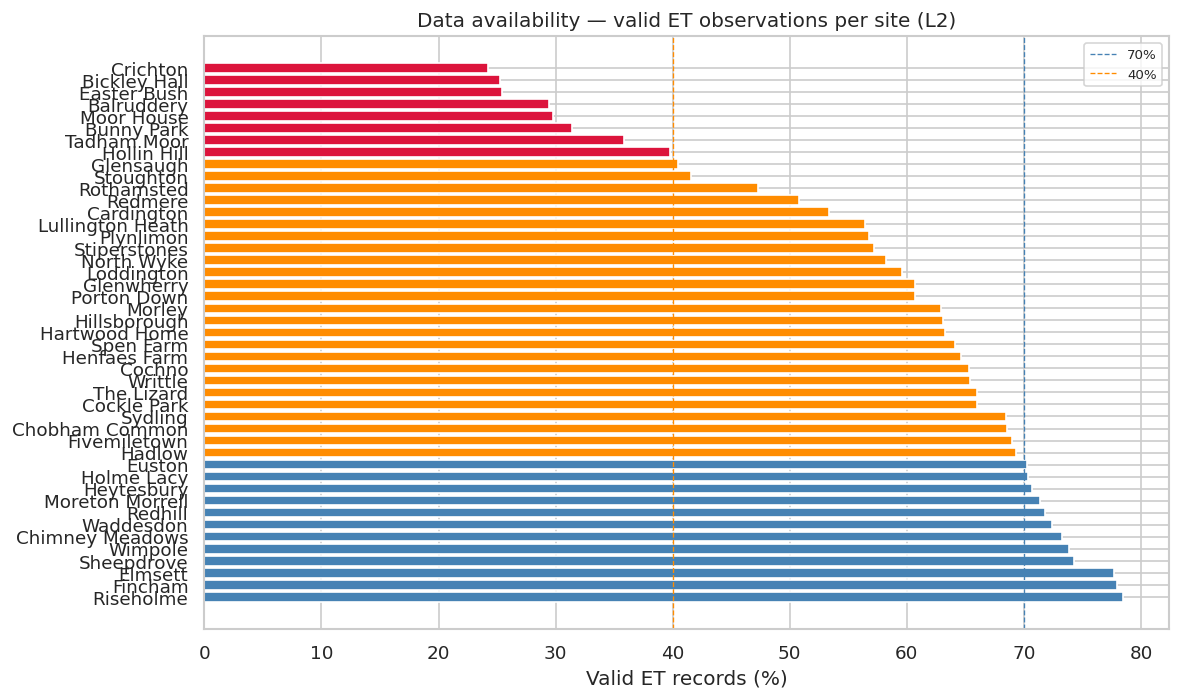

In [7]:
avail = (all_l2.groupby('SITE_ID')
         .agg(n_records=('ET', 'count'),
              n_total=('DATE_TIME', 'count'),
              date_start=('DATE_TIME', 'min'),
              date_end=('DATE_TIME', 'max'))
         .assign(pct_valid=lambda d: 100 * d['n_records'] / d['n_total']))

avail = avail.merge(meta[['SITE_ID','SITE_NAME','LAND_COVER']], on='SITE_ID')
avail = avail.sort_values('pct_valid', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = avail['pct_valid'].apply(
    lambda v: 'steelblue' if v >= 70 else 'darkorange' if v >= 40 else 'crimson')
ax.barh(avail['SITE_NAME'], avail['pct_valid'], color=colors)
ax.axvline(70, color='steelblue', linestyle='--', linewidth=0.8, label='70%')
ax.axvline(40, color='darkorange', linestyle='--', linewidth=0.8, label='40%')
ax.set_xlabel('Valid ET records (%)')
ax.set_title('Data availability — valid ET observations per site (L2)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Single-site time series

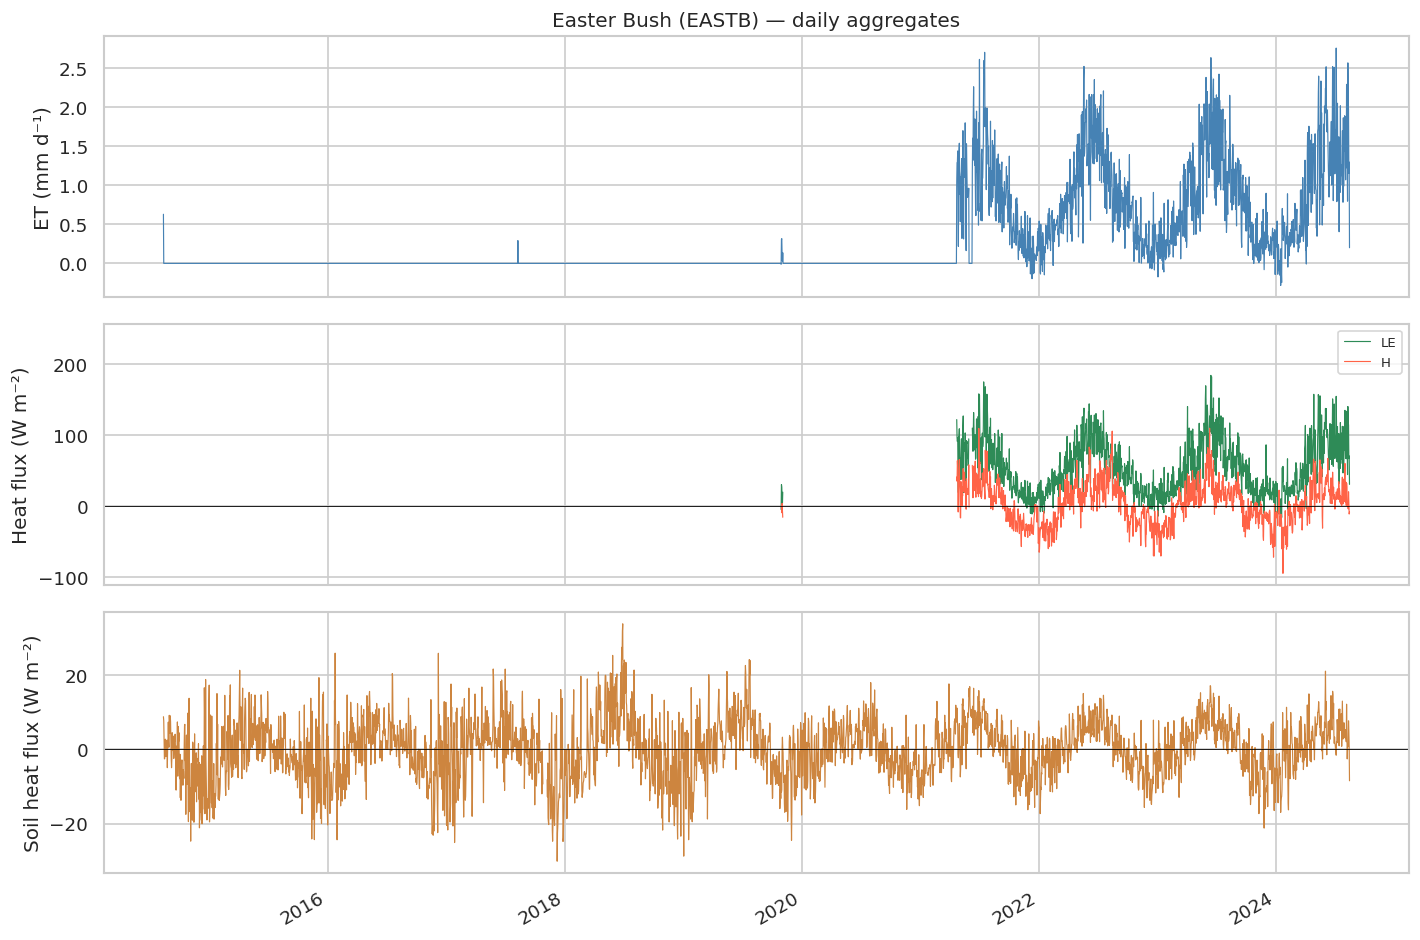

In [8]:
SITE = 'EASTB'  # change to any SITE_ID

site_df = (all_l2[all_l2['SITE_ID'] == SITE]
           .set_index('DATE_TIME')
           .sort_index())

daily = site_df[['H','LE','ET','SHF']].resample('D').agg(
    H=('H','mean'), LE=('LE','mean'), ET_daily=('ET','sum'), SHF=('SHF','mean')
)

site_name = meta.loc[meta['SITE_ID']==SITE, 'SITE_NAME'].values[0]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(daily.index, daily['ET_daily'], lw=0.7, color='steelblue')
axes[0].set_ylabel('ET (mm d⁻¹)')
axes[0].set_title(f'{site_name} ({SITE}) — daily aggregates')

axes[1].plot(daily.index, daily['LE'], lw=0.7, color='seagreen', label='LE')
axes[1].plot(daily.index, daily['H'],  lw=0.7, color='tomato',   label='H')
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set_ylabel('Heat flux (W m⁻²)')
axes[1].legend(fontsize=8)

axes[2].plot(daily.index, daily['SHF'], lw=0.7, color='peru')
axes[2].axhline(0, color='k', linewidth=0.5)
axes[2].set_ylabel('Soil heat flux (W m⁻²)')

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 5. Seasonal cycle

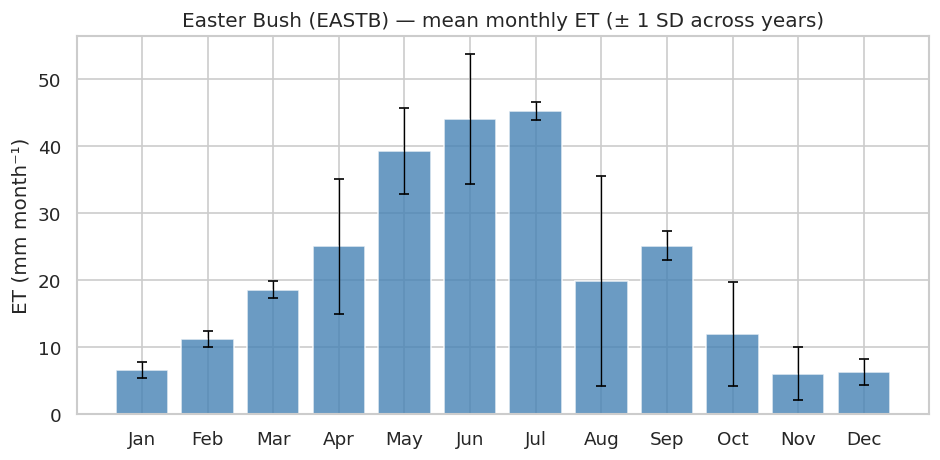

In [9]:
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

monthly_site = (all_l2[all_l2['SITE_ID'] == SITE]
                .dropna(subset=['ET'])
                .groupby(['YEAR','MONTH'])['ET']
                .sum()
                .reset_index()
                .groupby('MONTH')['ET']
                .agg(['mean','std']))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(monthly_site.index, monthly_site['mean'],
       yerr=monthly_site['std'], capsize=3,
       color='steelblue', alpha=0.8, error_kw={'elinewidth':0.8})
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_ylabel('ET (mm month⁻¹)')
ax.set_title(f'{site_name} ({SITE}) — mean monthly ET (± 1 SD across years)')
plt.tight_layout()
plt.show()

## 6. Multi-site seasonal comparison

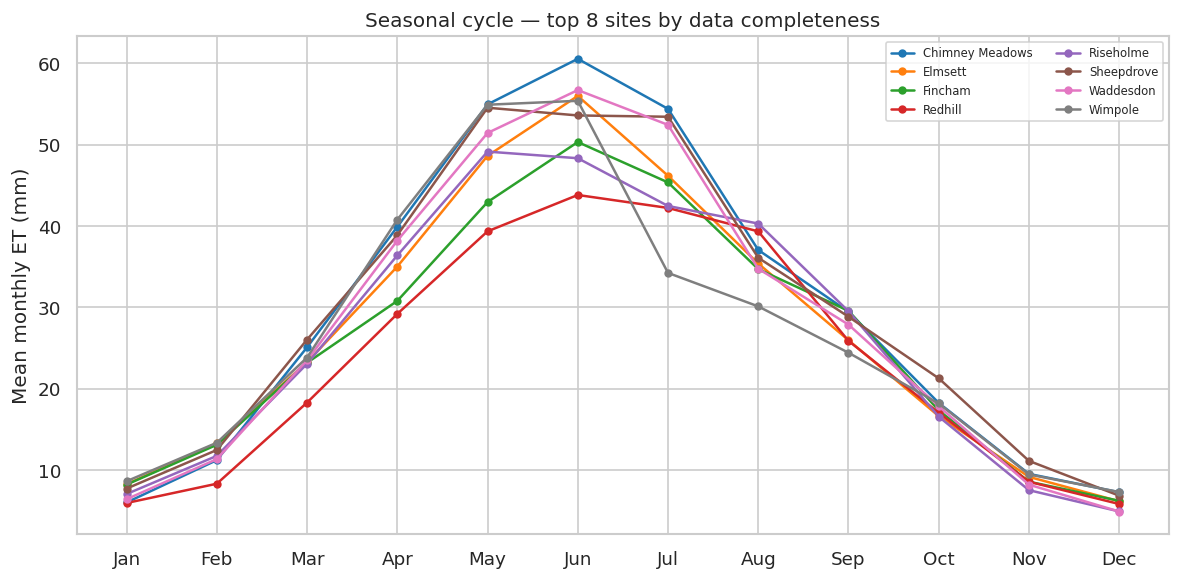

In [10]:
top_sites = avail.nlargest(8, 'pct_valid')['SITE_ID'].tolist()

monthly_all = (all_l2[all_l2['SITE_ID'].isin(top_sites)]
               .dropna(subset=['ET'])
               .groupby(['SITE_ID','YEAR','MONTH'])['ET']
               .sum()
               .reset_index()
               .groupby(['SITE_ID','MONTH'])['ET']
               .mean()
               .reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
for sid, grp in monthly_all.groupby('SITE_ID'):
    sname = meta.loc[meta['SITE_ID']==sid,'SITE_NAME'].values[0]
    ax.plot(grp['MONTH'], grp['ET'], marker='o', markersize=4, label=sname)

ax.set_xticks(range(1,13))
ax.set_xticklabels(month_labels)
ax.set_ylabel('Mean monthly ET (mm)')
ax.set_title('Seasonal cycle — top 8 sites by data completeness')
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

## 7. Annual ET by land cover

/tmp/ipykernel_2729918/1291709351.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=annual, x='LC_short', y='annual_ET_mm',


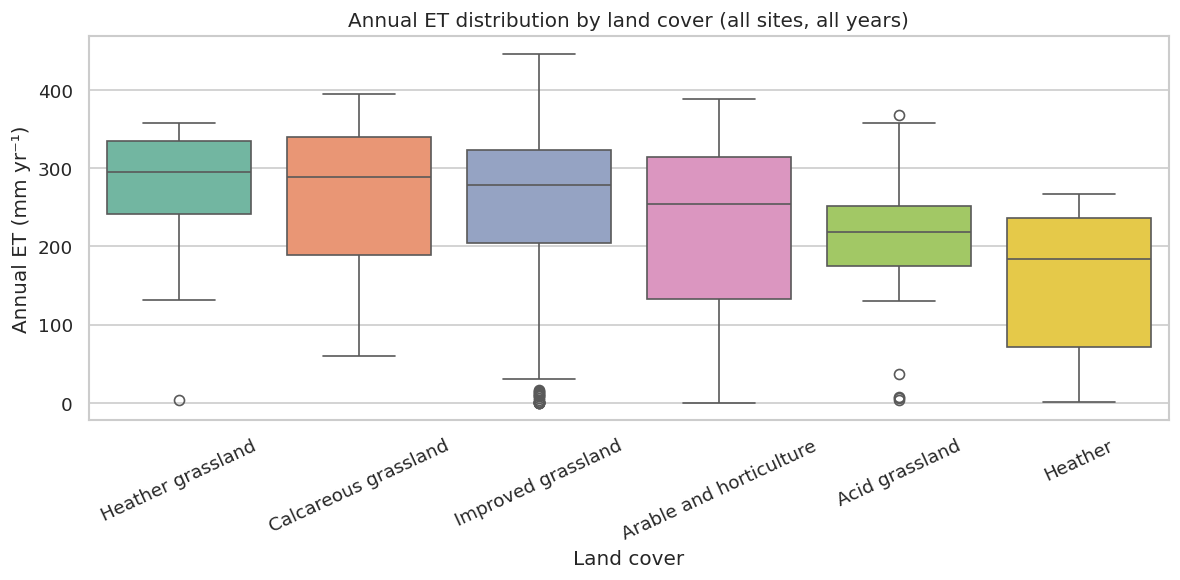

In [11]:
annual = (all_l2.dropna(subset=['ET'])
          .groupby(['SITE_ID','YEAR'])['ET']
          .sum()
          .reset_index(name='annual_ET_mm'))

annual = annual.merge(meta[['SITE_ID','LAND_COVER']], on='SITE_ID')
annual['LC_short'] = (annual['LAND_COVER']
                      .str.replace(r' \(.*\)', '', regex=True)
                      .str.strip())

fig, ax = plt.subplots(figsize=(10, 5))
order = (annual.groupby('LC_short')['annual_ET_mm']
         .median().sort_values(ascending=False).index)
sns.boxplot(data=annual, x='LC_short', y='annual_ET_mm',
            order=order, ax=ax, palette='Set2')
ax.set_xlabel('Land cover')
ax.set_ylabel('Annual ET (mm yr⁻¹)')
ax.set_title('Annual ET distribution by land cover (all sites, all years)')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

## 8. Interannual trend — network-wide mean ET

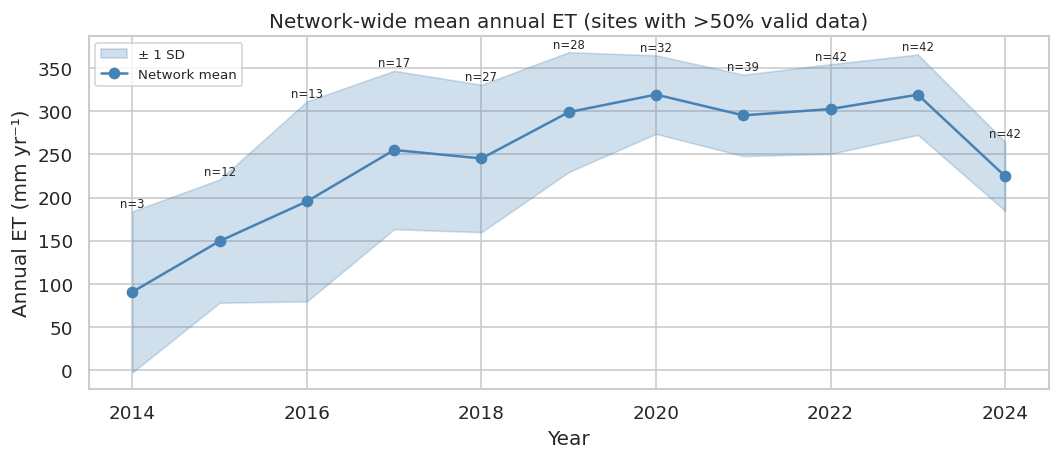

In [12]:
site_year_n = (all_l2.groupby(['SITE_ID','YEAR'])
               .agg(valid=('ET', 'count'), total=('DATE_TIME','count'))
               .assign(pct=lambda d: d['valid']/d['total'])
               .query('pct > 0.5'))

annual_filtered = annual.merge(
    site_year_n.reset_index()[['SITE_ID','YEAR']], on=['SITE_ID','YEAR'])

network_annual = (annual_filtered
                  .groupby('YEAR')['annual_ET_mm']
                  .agg(['mean','std','count'])
                  .reset_index())

fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(network_annual['YEAR'],
                network_annual['mean'] - network_annual['std'],
                network_annual['mean'] + network_annual['std'],
                alpha=0.25, color='steelblue', label='± 1 SD')
ax.plot(network_annual['YEAR'], network_annual['mean'],
        marker='o', color='steelblue', label='Network mean')
for _, row in network_annual.iterrows():
    ax.text(row['YEAR'], row['mean'] + row['std'] + 5,
            f"n={int(row['count'])}", ha='center', fontsize=7)
ax.set_xlabel('Year')
ax.set_ylabel('Annual ET (mm yr⁻¹)')
ax.set_title('Network-wide mean annual ET (sites with >50% valid data)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 9. Energy balance partitioning — H vs LE

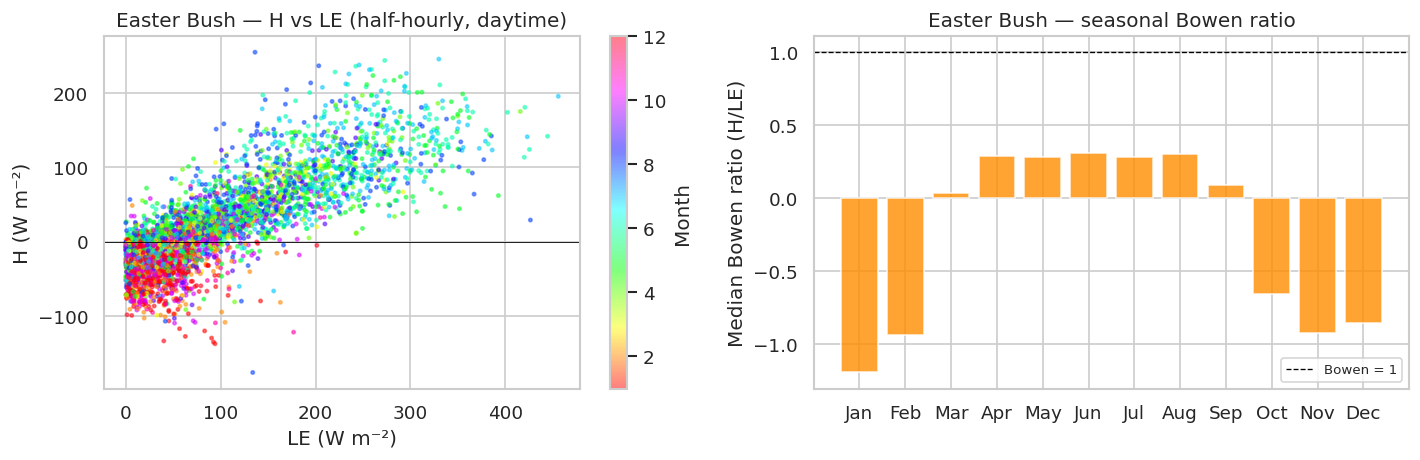

In [13]:
daytime = (all_l2[(all_l2['SITE_ID'] == SITE) & (all_l2['LE'] > 0)]
           .dropna(subset=['H','LE']))

daytime_monthly = (daytime
                   .assign(bowen=daytime['H'] / daytime['LE'])
                   .groupby('MONTH')['bowen']
                   .median())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sample = daytime.sample(min(5000, len(daytime)), random_state=42)
sc = axes[0].scatter(sample['LE'], sample['H'],
                     c=sample['MONTH'], cmap='hsv', s=4, alpha=0.5)
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].set_xlabel('LE (W m⁻²)')
axes[0].set_ylabel('H (W m⁻²)')
axes[0].set_title(f'{site_name} — H vs LE (half-hourly, daytime)')
plt.colorbar(sc, ax=axes[0], label='Month')

axes[1].bar(daytime_monthly.index, daytime_monthly.values,
            color='darkorange', alpha=0.8)
axes[1].axhline(1, color='k', linestyle='--', linewidth=0.8, label='Bowen = 1')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(month_labels)
axes[1].set_ylabel('Median Bowen ratio (H/LE)')
axes[1].set_title(f'{site_name} — seasonal Bowen ratio')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 10. Diurnal cycle

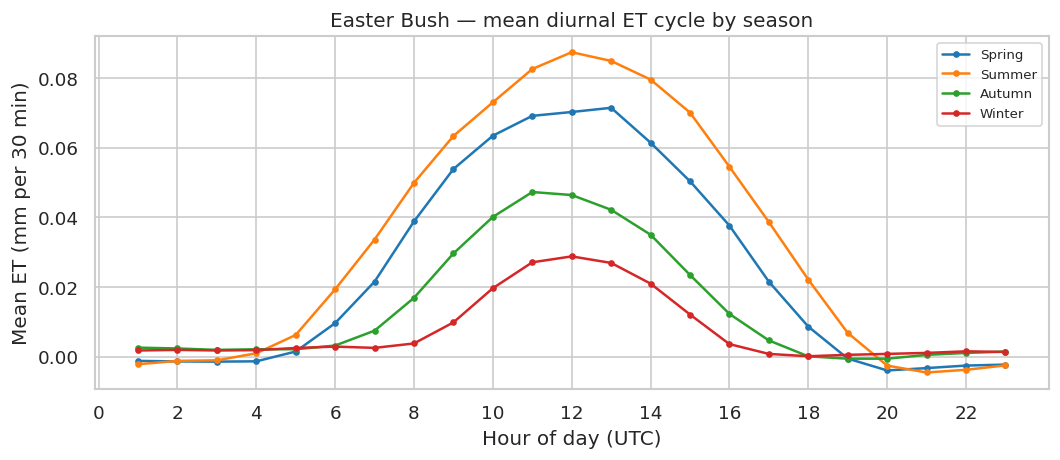

In [14]:
def month_to_season(m):
    if m in [12, 1, 2]: return 'Winter'
    if m in [3, 4, 5]:  return 'Spring'
    if m in [6, 7, 8]:  return 'Summer'
    return 'Autumn'

site_df2 = all_l2[all_l2['SITE_ID'] == SITE].copy()
site_df2['HOUR']   = site_df2['DATE_TIME'].dt.hour
site_df2['SEASON'] = site_df2['MONTH'].map(month_to_season)

diurnal = (site_df2.dropna(subset=['ET'])
           .groupby(['SEASON','HOUR'])['ET']
           .mean()
           .reset_index())

fig, ax = plt.subplots(figsize=(9, 4))
for season in ['Spring','Summer','Autumn','Winter']:
    grp = diurnal[diurnal['SEASON'] == season]
    ax.plot(grp['HOUR'], grp['ET'], marker='o', markersize=3, label=season)

ax.set_xlabel('Hour of day (UTC)')
ax.set_ylabel('Mean ET (mm per 30 min)')
ax.set_title(f'{site_name} — mean diurnal ET cycle by season')
ax.legend(fontsize=8)
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()